In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore")

In [6]:
df=pd.read_csv("data/hand-gestures.csv")
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,z12,z13,z14,z15,z16,z17,z18,z19,z20,label
0,0.000000,0.000000,0.000000,0.615611,-0.057947,-0.028228,1.135275,-0.293953,-0.109823,1.569514,...,-0.104329,-1.112674,-0.406334,-0.094003,-0.966976,-0.314087,-0.106826,-0.817667,-0.247338,thumbs_up
1,0.011424,-0.011763,0.006403,0.668221,-0.029268,-0.036391,1.206343,-0.317269,-0.117403,1.656298,...,-0.091140,-1.209031,-0.432008,-0.121875,-1.006015,-0.324465,-0.147142,-0.885972,-0.270880,thumbs_up
2,-0.029602,-0.017404,-0.003910,0.570343,-0.075560,-0.017216,1.140002,-0.275733,-0.130799,1.489458,...,-0.125482,-1.050329,-0.382855,-0.121580,-0.967410,-0.301745,-0.087365,-0.770450,-0.224523,thumbs_up
3,0.002341,0.015014,0.024093,0.676676,-0.066643,-0.014537,1.196976,-0.318869,-0.122742,1.642507,...,-0.133575,-1.198371,-0.450520,-0.124728,-1.033392,-0.329374,-0.136331,-0.919553,-0.214092,thumbs_up
4,0.004024,-0.005888,0.020364,0.551998,-0.071224,-0.038134,1.073272,-0.260239,-0.118999,1.498317,...,-0.114409,-1.075599,-0.402317,-0.113738,-0.932497,-0.310139,-0.080343,-0.771951,-0.249318,thumbs_up


In [8]:
print("Columns: \n",df.columns)
print("Null values:  \n",df.isnull().sum())
print("Duplicated values: \n",df.duplicated().sum())
print("Shape: \n",df.shape)

Columns: 
 Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20',
       'y0', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9', 'y10',
       'y11', 'y12', 'y13', 'y14', 'y15', 'y16', 'y17', 'y18', 'y19', 'y20',
       'z0', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z10',
       'z11', 'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z20',
       'label'],
      dtype='str')
Null values:  
 x0       0
x1       0
x2       0
x3       0
x4       0
        ..
z17      0
z18      0
z19      0
z20      0
label    0
Length: 64, dtype: int64
Duplicated values: 
 0
Shape: 
 (798, 64)


label
thumbs_up     438
open_palm     120
close_palm    120
peace         120
Name: count, dtype: int64


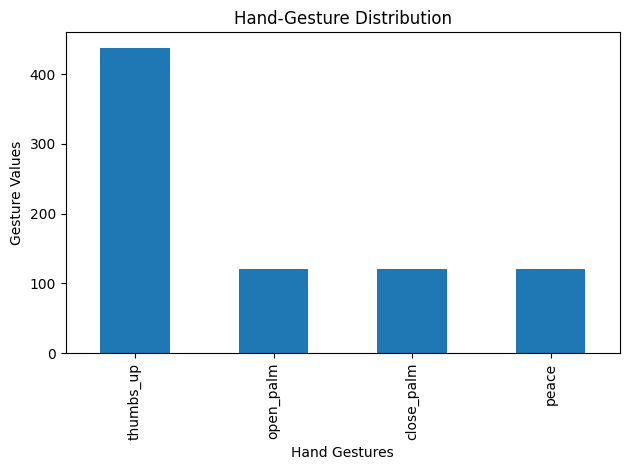

In [11]:
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")

plt.xlabel("Hand Gestures")
plt.ylabel("Gesture Values")
plt.title("Hand-Gesture Distribution")

plt.tight_layout()
plt.savefig("images/hand_gesture_distribution.png")

In [14]:
X=df.drop("label",axis=1)
y=df["label"]

In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,stratify=y 
    
)

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

y_train=encoder.fit_transform(y_train)
y_test=encoder.transform(y_test)

print(encoder.classes_)

['close_palm' 'open_palm' 'peace' 'thumbs_up']


In [19]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [25]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model=Sequential([
    Dense(64,activation="relu",input_shape=(63,)),
    Dense(32,activation="relu"),
    Dense(4,activation="softmax")
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,308 (24.64 KB)

 Trainable params: 6,308 (24.64 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

Epoch 1/50


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9833 - loss: 0.0800 - val_accuracy: 0.9417 - val_loss: 0.1365
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9895 - loss: 0.0738 - val_accuracy: 0.9667 - val_loss: 0.1299
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9916 - loss: 0.0693 - val_accuracy: 0.9417 - val_loss: 0.1335
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9812 - loss: 0.0669 - val_accuracy: 0.9583 - val_loss: 0.1085
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9937 - loss: 0.0634 - val_accuracy: 0.9583 - val_loss: 0.1170
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9895 - loss: 0.0592 - val_accuracy: 0.9750 - val_loss: 0.1008
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9937 - loss: 0.0554 - val_accuracy: 0.9500 - val_loss: 0.1097
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9937 - loss: 0.0509 - val_accuracy: 0.9750 - val_loss: 0.1006
Epo

In [29]:
test_loss,test_acc=model.evaluate(X_test,y_test)

print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9800 - loss: 0.0462 
Test Loss:  0.04617369547486305
Test Accuracy:  0.9800000190734863


In [30]:
y_prob=model.predict(X_test)
y_pred=y_prob.argmax(axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


In [34]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,confusion_matrix

print(
    classification_report(
        y_test,y_pred,target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

  close_palm       0.97      0.93      0.95        30
   open_palm       1.00      0.97      0.98        30
       peace       0.97      1.00      0.98        30
   thumbs_up       0.98      0.99      0.99       110

    accuracy                           0.98       200
   macro avg       0.98      0.97      0.98       200
weighted avg       0.98      0.98      0.98       200



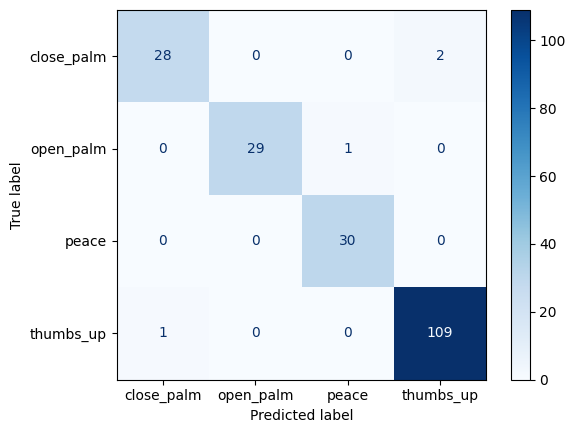

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.savefig("images/confusion_matrics.png")
plt.show()

In [39]:
wrong_idx = np.where(y_test != y_pred)[0]

print("Misclassified:", len(wrong_idx))

for i in wrong_idx:
    print(
        f"Index: {i}, "
        f"True: {encoder.classes_[y_test[i]]}, "
        f"Predicted: {encoder.classes_[y_pred[i]]}, "
        f"Confidence: {y_prob[i].max():.3f}"
    )

Misclassified: 4
Index: 6, True: open_palm, Predicted: peace, Confidence: 0.528
Index: 82, True: close_palm, Predicted: thumbs_up, Confidence: 0.663
Index: 162, True: close_palm, Predicted: thumbs_up, Confidence: 0.679
Index: 192, True: thumbs_up, Predicted: close_palm, Confidence: 0.669


In [40]:
X_test_original=X_test.copy()

In [41]:
from tensorflow.keras.layers import Dropout

model_dropout=Sequential([
    Dense(128,activation="relu",input_shape=(63,)),
    Dropout(0.3),

    Dense(64,activation="relu"),
    Dropout(0.3),
    Dense(4,activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,926 (73.93 KB)

 Trainable params: 6,308 (24.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,618 (49.29 KB)

In [42]:
model_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
history_dropout=model_dropout.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4937 - loss: 1.1090 - val_accuracy: 0.5000 - val_loss: 0.9955
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6046 - loss: 0.8894 - val_accuracy: 0.5500 - val_loss: 0.9027
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7050 - loss: 0.7706 - val_accuracy: 0.6917 - val_loss: 0.7867
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7427 - loss: 0.7076 - val_accuracy: 0.7250 - val_loss: 0.7080
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7824 - loss: 0.6117 - val_accuracy: 0.7583 - val_loss: 0.6420
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8305 - loss: 0.5478 - val_accuracy: 0.7667 - val_loss: 0.5703
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8201 - loss: 0.5036 - val_accuracy: 0.8417 - val_loss: 0.5201
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8473 - loss: 0.4746 - val_accuracy: 0.8583 - val_loss

In [44]:
test_loss,test_acc=model_dropout.evaluate(X_test,y_test)

print("Test Accuracy: ",test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9500 - loss: 0.0869 
Test Accuracy:  0.949999988079071


In [46]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{0: 1.6611111111111112, 1: 1.6611111111111112, 2: 1.6611111111111112, 3: 0.4557926829268293}


In [47]:
model_weighted = Sequential([
    Dense(64, activation="relu", input_shape=(63,)),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])
model_weighted.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [48]:
history_weighted = model_weighted.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3536 - loss: 1.3080 - val_accuracy: 0.5083 - val_loss: 1.1532
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6464 - loss: 1.1106 - val_accuracy: 0.6500 - val_loss: 0.9951
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7385 - loss: 0.9668 - val_accuracy: 0.7333 - val_loss: 0.8290
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8096 - loss: 0.8300 - val_accuracy: 0.8417 - val_loss: 0.7045
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8494 - loss: 0.6923 - val_accuracy: 0.8583 - val_loss: 0.6028
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8598 - loss: 0.5900 - val_accuracy: 0.8417 - val_loss: 0.5462
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8891 - loss: 0.5006 - val_accuracy: 0.8417 - val_loss: 0.4797
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8870 - loss: 0.4369 - val_accuracy: 0.8583 - val_loss

In [49]:
test_loss, test_acc = model_weighted.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9950 - loss: 0.0530 
Test Accuracy: 0.9950000047683716


In [50]:
y_prob_weighted=model_weighted.predict(X_test)
y_pred_weighted=y_prob_weighted.argmax(axis=1)

print(
    classification_report(
        y_test,
        y_pred_weighted,
        target_names=encoder.classes_
    )
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
              precision    recall  f1-score   support

  close_palm       1.00      0.97      0.98        30
   open_palm       1.00      1.00      1.00        30
       peace       1.00      1.00      1.00        30
   thumbs_up       0.99      1.00      1.00       110

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



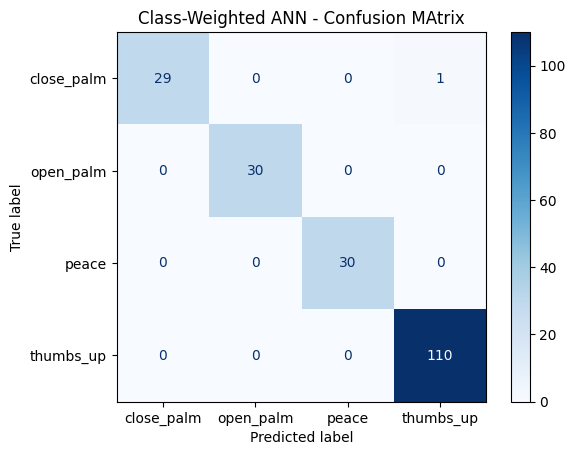

In [52]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_weighted,
    display_labels=encoder.classes_,
    cmap="Blues"
)
plt.title("Class-Weighted ANN - Confusion MAtrix")
plt.savefig("images/class_weight_model_cm.png")

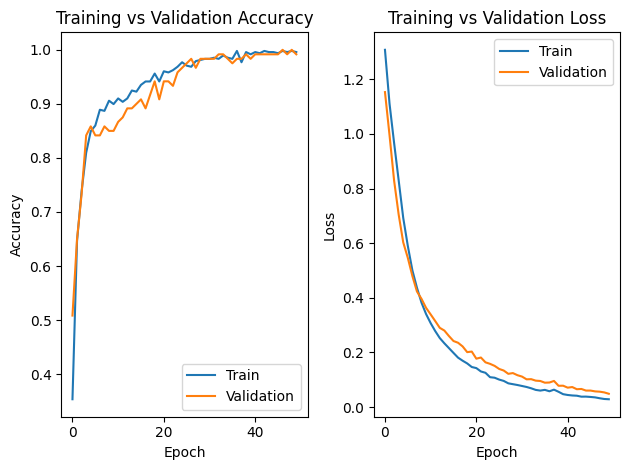

In [53]:
plt.subplot(1, 2, 1)
plt.plot(history_weighted.history["accuracy"], label="Train")
plt.plot(history_weighted.history["val_accuracy"], label="Validation")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("images/training_validation_Accuracy.png")

plt.subplot(1, 2, 2)
plt.plot(history_weighted.history["loss"], label="Train")
plt.plot(history_weighted.history["val_loss"], label="Validation")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("images/training_validation_loss.png")

plt.tight_layout()

In [54]:
model_weighted.save("hand_gesture_ann.keras")

In [56]:
import joblib

print(joblib.dump(scaler,"scaler.pkl"))
print(joblib.dump(encoder,"LabelEncoder.pkl"))

['scaler.pkl']
['LabelEncoder.pkl']


In [57]:

def predict_gesture(landmarks):
    """
    landmarks: array/list containing 63 values
    order: x0...x20, y0...y20, z0...z20
    """
    
    landmarks = np.array(landmarks).reshape(1, -1)

    # Same preprocessing used during training
    landmarks_scaled = scaler.transform(landmarks)

    # Prediction
    probabilities = model_weighted.predict(landmarks_scaled, verbose=0)

    predicted_class = np.argmax(probabilities[0])
    confidence = probabilities[0][predicted_class]

    gesture = encoder.inverse_transform([predicted_class])[0]

    return gesture, confidence



In [58]:
sample = X_test[0]

predict_gesture(scaler.inverse_transform(sample.reshape(1, -1))[0])

('thumbs_up', 0.80926913)

In [60]:
sample_idx = 0

sample_raw = scaler.inverse_transform(
    X_test[sample_idx].reshape(1, -1)
)

gesture, confidence = predict_gesture(sample_raw[0])

print("Actual:", encoder.classes_[y_test[sample_idx]])
print("Predicted:", gesture)
print("Confidence:", confidence)

Actual: thumbs_up
Predicted: thumbs_up
Confidence: 0.80926913


In [62]:
probabilities = model_weighted.predict(
    X_test[sample_idx].reshape(1, -1),
    verbose=0
)[0]

for label, prob in zip(encoder.classes_, probabilities):
    print(f"{label}: {prob:.4f}")

close_palm: 0.0043
open_palm: 0.1864
peace: 0.0001
thumbs_up: 0.8093
